In [2]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\baw61\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_DA = df[df['job_title_short'] == 'Data Analyst']

In [4]:
df_exploded = df.explode('job_skills')

skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills', 'count'),
    median_salary=('salary_year_avg', 'median')
)

skills_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(10)

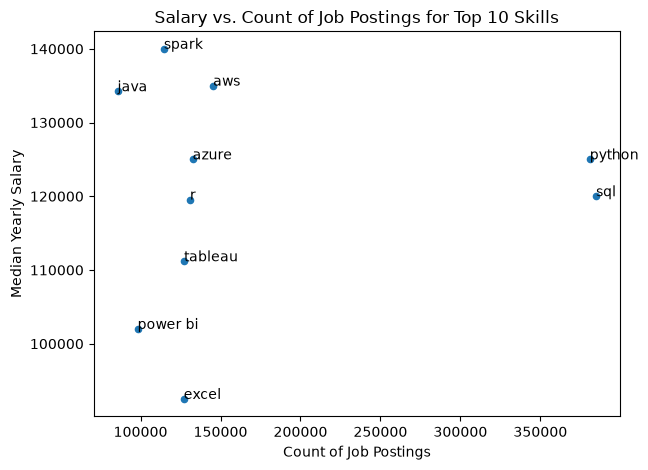

In [5]:
skills_stats.plot(kind='scatter', x='skill_count', y='median_salary')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title('Salary vs. Count of Job Postings for Top 10 Skills')
plt.tight_layout()

for i, txt in enumerate(skills_stats.index):
    plt.text(skills_stats['skill_count'].iloc[i], skills_stats['median_salary'].iloc[i], txt)
plt.show()

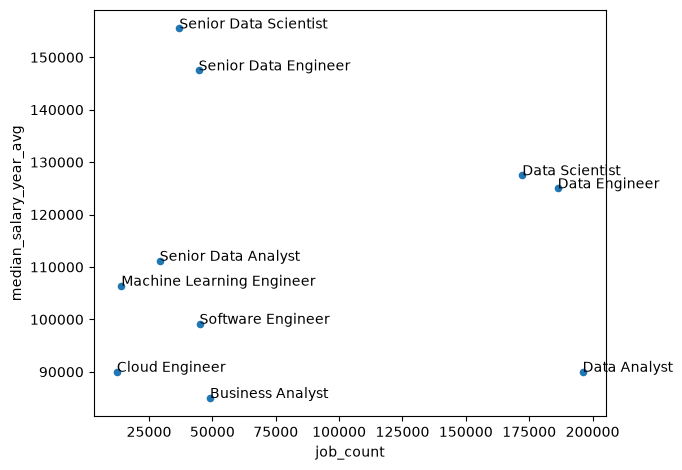

In [6]:
new = df.groupby('job_title_short').agg(
    median_salary_year_avg=('salary_year_avg', 'median'),
    job_count=('job_title_short', 'count')
)

new.plot(kind='scatter', x='job_count', y='median_salary_year_avg')
plt.tight_layout()
for i, txt in enumerate(new.index):
    plt.text(new['job_count'].iloc[i], new['median_salary_year_avg'].iloc[i], txt)
plt.show()

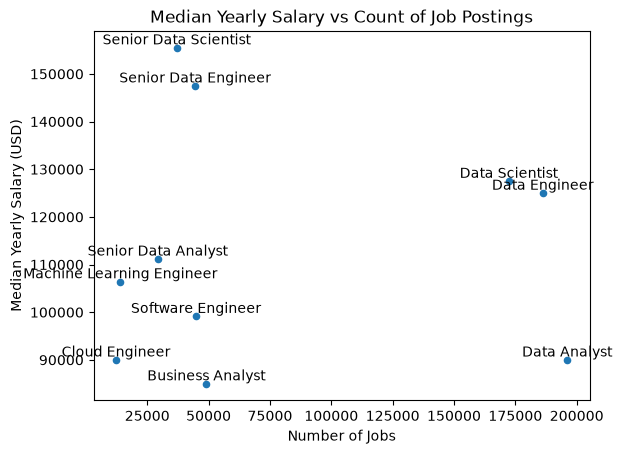

In [7]:
# Group data by job title and calculate average yearly salary and job count
job_title_stats = df.groupby('job_title_short').agg(
   median_salary_year_avg=('salary_year_avg', 'median'),
   job_count=('job_title_short', 'count')
).dropna()

# Plotting the results
job_title_stats.plot(kind='scatter', x='job_count', y='median_salary_year_avg')
plt.xlabel('Number of Jobs')
plt.ylabel('Median Yearly Salary (USD)')
plt.title('Median Yearly Salary vs Count of Job Postings')

# Adding job title labels to each point
for i in range(len(job_title_stats)):
   job_count = job_title_stats['job_count'].iloc[i]
   mean_salary = job_title_stats['median_salary_year_avg'].iloc[i]
   job_title = job_title_stats.index[i]
   plt.text(job_count, mean_salary, job_title, ha='center', va='bottom')

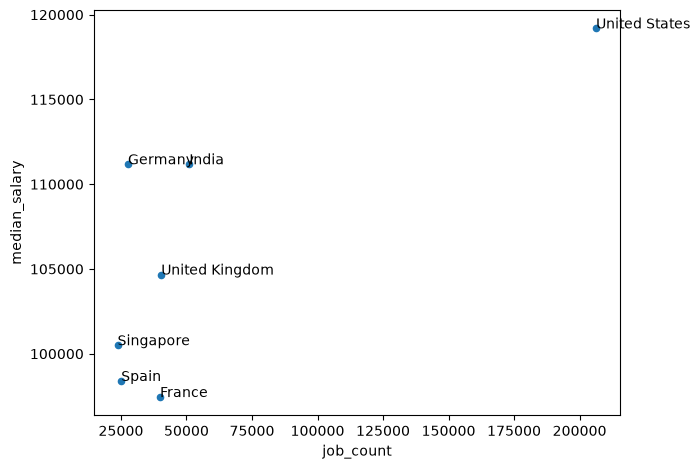

,median_salary,job_count
job_country,,
United States,119187.5,206292
India,111175.0,51088
United Kingdom,104668.0,40375
France,97444.0,39922
Germany,111175.0,27694
Spain,98391.5,25100
Singapore,100500.0,23696


In [8]:
new_data = df.groupby('job_country').agg(
    median_salary=('salary_year_avg', 'median'),
    job_count=('job_title_short', 'count')
).sort_values('job_count', ascending=False).head(7)

new_data.plot(kind='scatter', x='job_count', y='median_salary')
plt.tight_layout()
for i, txt in enumerate(new_data.index):
    plt.text(new_data['job_count'].iloc[i], new_data['median_salary'].iloc[i], txt)
plt.show()
new_data

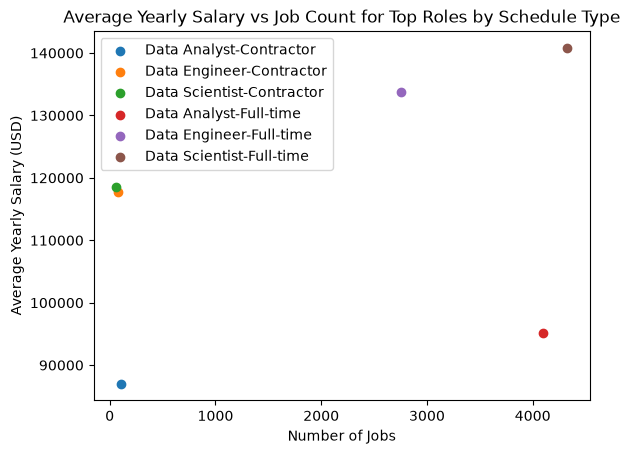

In [12]:
target_job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

us_jobs_df = df[
    (df['job_country'] == 'United States') &
    (df['job_schedule_type'].isin(['Full-time', 'Contractor'])) &
    (df['job_title_short'].isin(target_job_titles))
].dropna(subset=['salary_year_avg']).copy()

stats = us_jobs_df.groupby(['job_schedule_type', 'job_title_short']).agg(
    mean_salary_year_avg=('salary_year_avg', 'mean'),
    job_count=('job_title_short', 'count')
).dropna()

stats.reset_index(inplace=True)

stats['job_title_type'] = stats['job_title_short'] + '-' + stats['job_schedule_type']

for job_title_type in stats['job_title_type']:
    subset = stats[stats['job_title_type'] == job_title_type]
    plt.scatter(subset['job_count'], subset['mean_salary_year_avg'], label=job_title_type)

plt.xlabel('Number of Jobs')
plt.ylabel('Average Yearly Salary (USD)')
plt.title('Average Yearly Salary vs Job Count for Top Roles by Schedule Type')
plt.legend()
plt.show()
